In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr


/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from plm_compare_esm import *
from protein_data import *

In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/esm2_ProGym_matrices.pickle',
          'rb') as f:
    esm_dict = pickle.load(f)

names = list(pg_dict.keys())

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model_name = "hugohrban/progen2-medium"
model, tokenizer = initialize_progen2(model_name)

Using cpu device


In [7]:
pg_dict[names[3]].keys()

dict_keys(['sequence', 'DMS', 'log_probs', 'ref_log_probs', 'llr_matrix', 'spearman_DMS', 'log_probs_forward', 'ref_log_probs_forward', 'llr_matrix_forward', 'log_probs_backward', 'ref_log_probs_backward', 'llr_matrix_backward'])

In [12]:
for i in range(10):
    name = names[i]
    seq  = pg_dict[name]['sequence']
    lenseq = len(seq)
    sp_DMS = pg_dict[names[i]]['spearman_DMS'][0]

    print(i, name, lenseq, sp_DMS)

0 SDA_BACSU 44 0.3791506937886044
1 PAI1_HUMAN 402 0.3830853868977005
2 S22A1_HUMAN 553 0.5818748160195195
3 HIS7_YEAST 220 -0.019711807976736405
4 AMIE_PSEAE 346 0.6176898893049108
5 ACE2_HUMAN 805 0.09800182835485031
6 RDRP_I33A0 757 0.33020693561011744
7 CASP3_HUMAN 258 0.544815969481733
8 RL40A_YEAST 128 0.19197416052820312
9 SRC_HUMAN 536 0.39512094374115914


In [13]:
i = 5
name = names[i]

seq = pg_dict[name]['sequence']

lp, rp, llr = collect_logprob_pg2_cond(seq, model, tokenizer)

In [14]:
i = 5
name = names[i]
lp_avg = pg_dict[name]['log_probs']
llr_avg = pg_dict[name]['llr_matrix']
dms = pg_dict[name]['DMS']
lp_cond = lp
llr_cond = llr

In [15]:
sp_val_avg, p = spearman_ignore_nan(dms, llr_avg)
sp_val_cond, p = spearman_ignore_nan(dms, llr_cond)
print(sp_val_avg)
print(sp_val_cond)

0.09800182835485031
0.015286955988431234


In [10]:
lp_cond

array([[-2.3256838, -4.107582 , -2.7062228, ..., -2.7541125, -4.4082794,
        -3.6687853],
       [-2.3755145, -4.2859836, -3.0311694, ..., -2.6352267, -4.280544 ,
        -3.6432376],
       [-2.4549918, -4.1625113, -2.7024512, ..., -2.2830787, -4.061437 ,
        -2.958097 ],
       ...,
       [-4.1194625, -5.7725234, -6.8526626, ..., -2.716867 , -4.7559447,
        -2.9406981],
       [-4.3794937, -4.874321 , -5.098488 , ..., -2.3742068, -5.922447 ,
        -3.6926577],
       [-4.030854 , -5.994111 , -2.5887308, ..., -5.020509 , -7.0533   ,
        -4.6446238]], shape=(248, 20), dtype=float32)

In [9]:
lp_avg

array([[-3.4449475, -5.1298227, -3.6919873, ..., -2.577119 , -5.462693 ,
        -4.32277  ],
       [-2.9649954, -5.6701345, -2.345687 , ..., -3.685874 , -5.1736746,
        -3.8269186],
       [-2.9645631, -5.156603 , -2.6431901, ..., -3.1800706, -5.0883656,
        -3.8826768],
       ...,
       [-2.934937 , -4.5859838, -4.1952443, ..., -2.5835652, -4.383164 ,
        -3.158753 ],
       [-3.1469376, -4.363841 , -3.7591202, ..., -2.3244736, -4.840678 ,
        -3.489833 ],
       [-3.1352713, -4.920763 , -2.549044 , ..., -3.7479575, -5.49074  ,
        -4.1391697]], shape=(248, 20), dtype=float32)

In [ ]:
# for name in names:
#     seq = pg_dict[name]['sequence']
#     if len(seq) < 1024:
#         lp_forward, ref_forward, llr_forward = collect_log_prob_pg2_forward(seq, model, tokenizer)
#         lp_backward, ref_backward, llr_backward = collect_log_prob_pg2_backward(seq, model, tokenizer)

#         pg_dict[name]['log_probs_forward'] = lp_forward
#         pg_dict[name]['ref_log_probs_forward'] = ref_forward
#         pg_dict[name]['llr_matrix_forward'] = llr_forward

#         pg_dict[name]['log_probs_backward'] = lp_backward
#         pg_dict[name]['ref_log_probs_backward'] = ref_backward
#         pg_dict[name]['llr_matrix_backward'] = llr_backward


In [ ]:
# with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
#            'wb') as f:
#     pickle.dump(pg_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

In [4]:
# 4 seems to be the best integer to divide by for using back_end only at the front

count = 0
for name in names:
    seq = pg_dict[name]['sequence']
    n = len(seq)
    if n < 1024:
        dms = pg_dict[name]['DMS']
        llr = pg_dict[name]['llr_matrix']
        llrf = pg_dict[name]['llr_matrix_forward']
        llrb = pg_dict[name]['llr_matrix_backward']

        back_end = int(np.floor(n/4))

        sp_val, p = spearman_ignore_nan(dms[0:back_end], llr[0:back_end])
        sp_valf, pf = spearman_ignore_nan(dms[0:back_end], llrf[0:back_end])
        sp_valb, pb = spearman_ignore_nan(dms[0:back_end], llrb[0:back_end])

        if sp_valb > sp_val:
            count = count + 1

        print(sp_val, sp_valf, sp_valb)

print()
print(len(names))
print(count)

0.425187969924812 0.05007492507492508 0.4866081287133919
0.2557850125725817 0.13140830515291693 0.3081257434568672
0.51471100576541 0.389377965881021 0.522519180144349
-0.08799197214486104 0.03269426487951259 -0.13521702141526812
0.5396592947756352 0.4138705340934541 0.5379072046589892
0.2830023759780745 0.04539949289690999 0.3380799756109623
0.2758685936891773 0.18259529107960984 0.3206422335834946
0.2970608592636309 0.0951386794479293 0.4356669933403383
0.09042114646310188 0.03709489554230781 0.2601666134956906
nan nan nan
0.5407751753183543 -0.02351062926782576 0.5798951430991481
nan nan nan
0.6710241671256786 0.46574942670196523 0.7225633676623233
nan nan nan
0.6834447461797877 0.5904518864901371 0.6808014207367071
0.34158417744020925 0.34907005317740325 0.26216941124722243
0.14300587445820775 -0.12933224791533743 0.22441530439374271
0.3006533119548849 0.12060072600707124 0.30712113177799355
0.028195066055955814 -0.07192136738446754 0.1413537498462767
-0.016576783991131244 -0.13486

In [5]:
# 4 seems to be the best integer to divide by for using back_end only at the front
# 9 seems to be the best integer to divide by for using front_beg only at the end

count = 0
for name in names:
    seq = pg_dict[name]['sequence']
    n = len(seq)
    if n < 1024:
        dms = pg_dict[name]['DMS']
        llr = pg_dict[name]['llr_matrix']
        llrf = pg_dict[name]['llr_matrix_forward']
        llrb = pg_dict[name]['llr_matrix_backward']

        back_end = int(np.floor(n/4))
        front_beg = int(n - np.floor(n/9)) 

        sp_val, p = spearman_ignore_nan(dms[front_beg:], llr[front_beg:])
        sp_valf, pf = spearman_ignore_nan(dms[front_beg:], llrf[front_beg:])
        sp_valb, pb = spearman_ignore_nan(dms[front_beg:], llrb[front_beg:])

        if sp_valf > sp_val:
            count = count + 1

        print(sp_val, sp_valf, sp_valb)

print()
print(len(names))
print(count)

-0.03130553656869446 -0.004757347915242652 -0.07026657552973342
0.3905741005757309 0.3849269614488918 0.2887519173664065
0.5414192817513322 0.5146780761707707 0.4605762212680368
0.03186274509803922 0.029411764705882353 -0.02450980392156863
0.027642651138181207 -0.014642709988174196 0.1993037328476397
nan nan nan
0.24320372964417278 0.2630570989782209 0.1691289950315616
0.6086551983202019 0.6228988075745024 0.2038739380863401
nan nan nan
0.37863358934362473 0.3888801285293504 0.2814532444735354
0.7200190703635179 0.7350286711543257 0.24134419819181463
nan nan nan
0.4919984096772431 0.5379291977502922 0.1265509317306388
0.35159479949055 0.37260013114846796 0.24294191027831216
nan nan nan
nan nan nan
0.2884588693748999 0.2900443068382 -0.009064218224523569
0.08295239370349826 0.22561189424223296 -0.29006879227792337
-0.006827548028622394 0.10075246550345478 -0.2688611868588495
-0.20073690864328966 -0.1831791869053164 -0.040696320447135545
-0.04072231245320768 0.08768868893040081 -0.112607

In [6]:
# 4 seems to be the best integer to divide by for using back_end only at the front
# 9 seems to be the best integer to divide by for using front_beg only at the end

count = 0
for name in names:
    seq = pg_dict[name]['sequence']
    n = len(seq)
    if n < 1024:
        dms = pg_dict[name]['DMS']
        llr = pg_dict[name]['llr_matrix']
        llrf = pg_dict[name]['llr_matrix_forward']
        llrb = pg_dict[name]['llr_matrix_backward']

        back_end = int(np.floor(n/4))
        front_beg = int(n - np.floor(n/9)) 

        sp_val, p = spearman_ignore_nan(dms[back_end:front_beg], llr[back_end:front_beg])
        sp_valf, pf = spearman_ignore_nan(dms[back_end:front_beg], llrf[back_end:front_beg])
        sp_valb, pb = spearman_ignore_nan(dms[back_end:front_beg], llrb[back_end:front_beg])

        if sp_val > sp_valf and sp_val > sp_valb:
            count = count + 1

        print(sp_val, sp_valf, sp_valb)

print()
print(len(names))
print(count)

0.3723061308863839 0.3780381085176964 0.03293028116292839
0.4267375057779139 0.408414178890982 0.38415435696009737
0.6113560587114553 0.5852645098965461 0.5559417123423457
0.0020001388985346202 -0.05356621987638029 0.030557677616501137
0.6045007421608611 0.5318620132207086 0.554687589325875
-0.09725160566620593 -0.11149257147227616 -0.05630077565387713
0.3702528272794575 0.27515052203319973 0.3652280599723432
0.634618534965744 0.6213089545185354 0.5834157578947998
0.1595036712532586 0.2432378663463126 0.07148564941457053
0.38331599115298776 0.3215145096961603 0.3843161474080495
0.6019876739301767 0.4745720177641852 0.5575984140807784
0.2556418803101082 0.07964181422417174 0.3464059576471754
0.6793047743680661 0.6885338252565852 0.5916717687264661
nan nan nan
0.6261578821454349 0.5843479964016967 0.619973824706935
0.43746829194712195 0.38235352529631655 0.42961559509599323
0.4176919321796285 0.17872299756424398 0.41273430505562714
0.2705691960255445 0.26439784554957096 0.167866190848671

In [6]:
for i in range(15):
    name = names[i]
    seq = pg_dict[name]['sequence']
    if len(seq) < 1024:
        lp_forward, ref_forward, llr_forward = collect_log_prob_pg2_forward(seq, model, tokenizer)
        lp_backward, ref_backward, llr_backward = collect_log_prob_pg2_backward(seq, model, tokenizer)

        x = pg_dict[name]['DMS']
        y1 = pg_dict[name]['llr_matrix']
        y2 = llr_forward
        y3 = llr_backward
        print(name)
        sp_val1, p_val1 = spearman_ignore_nan(x, y1)
        print(float(sp_val1))
        sp_val2, p_val2 = spearman_ignore_nan(x,y2)
        print(float(sp_val2))
        sp_val3, p_val3 = spearman_ignore_nan(x,y3)
        print(float(sp_val3))
        print()

SDA_BACSU
0.3791506937886044
0.26904306204748496
0.15519772253393813

PAI1_HUMAN
0.3830853868977005
0.34464203073016564
0.35566469347667307

S22A1_HUMAN
0.5818748160195195
0.5182366812455503
0.5440696418652146

HIS7_YEAST
-0.019711807976736405
-0.0049137157587255224
-0.03789622606916128

AMIE_PSEAE
0.6176898893049108
0.500829379063913
0.5911915560559882

ACE2_HUMAN
0.09800182835485031
0.0003394865790570384
0.1526620622894378

RDRP_I33A0
0.33020693561011744
0.24863443322045664
0.32569575943690876

CASP3_HUMAN
0.544815969481733
0.5059381212043337
0.485349751491394

RL40A_YEAST
0.19197416052820312
0.2368130145463681
0.16207776306326357

SRC_HUMAN
0.39512094374115914
0.34475327515775483
0.3818112255852232

TRPC_SACS2
0.5818908474090954
0.4230541026034175
0.4621736830738076

GLPA_HUMAN
0.2556418803101082
0.07964181422417174
0.3464059576471754

BLAT_ECOLX
0.6155798918559141
0.5920879066325186
0.5417469905366104

LYAM1_HUMAN
0.35159479949055
0.37260013114846796
0.24294191027831216

PABP_YEAST

In [5]:
seq = pg_dict['CBPA2_HUMAN']['sequence']
print(len(seq), seq)
lp_forward, ref_forward, llr_forward = collect_log_prob_pg2_forward(seq, model, tokenizer)

72 VGDQVLEIVPSNEEQIKNLLQLEAQEHLQLDFWKSPTTPGETAHVRVPFVNVQAVKVFLESQGIAYSIMIED


In [6]:
lp_backward, ref_backward, llr_backward = collect_log_prob_pg2_backward(seq, model, tokenizer)

In [7]:
lp_backward

array([[-2.872014 , -4.573964 , -2.9334002, ..., -2.6832933, -4.5063677,
        -3.2890062],
       [-2.7978752, -4.7564325, -2.9569023, ..., -2.8355644, -4.47915  ,
        -3.458367 ],
       [-2.9098434, -4.2323074, -3.0707474, ..., -2.7323227, -4.437065 ,
        -3.321907 ],
       ...,
       [-2.634235 , -4.424022 , -2.9708667, ..., -2.8620486, -4.4668765,
        -3.44659  ],
       [-2.5773036, -4.334529 , -2.9186046, ..., -2.79156  , -4.479129 ,
        -3.723727 ],
       [-2.7903996, -4.127825 , -3.1435795, ..., -2.9184437, -4.3287525,
        -3.8262424]], shape=(72, 20), dtype=float32)

In [8]:
name = 'CBPA2_HUMAN'

x = pg_dict[name]['DMS']
y1 = pg_dict[name]['llr_matrix']
y2 = llr_forward
y3 = llr_backward
print(x.shape,y1.shape, y2.shape)

seq = pg_dict[name]['sequence']
print(seq)
print(len(seq))

sp_val1, p_val1 = spearman_ignore_nan(x, y1)
print(float(sp_val1))
sp_val2, p_val2 = spearman_ignore_nan(x,y2)
print(float(sp_val2))
sp_val3, p_val3 = spearman_ignore_nan(x,y3)
print(float(sp_val3))


(72, 20) (72, 20) (72, 20)
VGDQVLEIVPSNEEQIKNLLQLEAQEHLQLDFWKSPTTPGETAHVRVPFVNVQAVKVFLESQGIAYSIMIED
72
0.1355591489023103
0.09298793625934283
0.13632293309846685


In [26]:
def softmax(x, axis=None):
    x = np.asarray(x)
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

In [48]:
name = 'CBPA2_HUMAN'
T = 100

A1 = esm_dict[name]['log_probs']
A2 = pg_dict[name]['log_probs']
eA1 = np.exp(A1)
eA2 = np.exp(A2)
Bf = lp_forward
eBf = np.exp(Bf)
sfeBf = softmax(T*eBf, axis=1)

print(Bf[1])
print(eBf[1]) 
print(sfeBf[1])
print(np.sum(Bf[1]), np.sum(eBf[1]),np.sum(sfeBf[1]))

[-2.3927462 -4.1259766 -3.0653613 -2.955063  -3.2051318 -2.5990908
 -3.7966769 -3.0953906 -3.190842  -2.3435442 -4.4075394 -3.3159869
 -2.7393496 -3.2544253 -2.575905  -2.4638216 -2.740227  -2.7689974
 -4.4338226 -3.8843234]
[0.0913784  0.01614772 0.04663699 0.05207537 0.04055356 0.07434114
 0.02244524 0.04525733 0.04113722 0.09598684 0.01218512 0.03629821
 0.06461236 0.038603   0.07608493 0.08510907 0.06455569 0.06272486
 0.01186903 0.02056174]
[2.6465482e-01 1.4303841e-04 3.0170672e-03 5.1972196e-03 1.6420445e-03
 4.8168249e-02 2.6850388e-04 2.6282535e-03 1.7407367e-03 4.1958639e-01
 9.6240852e-05 1.0729447e-03 1.8207291e-02 1.3510556e-03 5.7344615e-02
 1.4138593e-01 1.8104399e-02 1.5075514e-02 9.3246301e-05 2.2240826e-04]
-63.354218 0.9985639 0.99999994


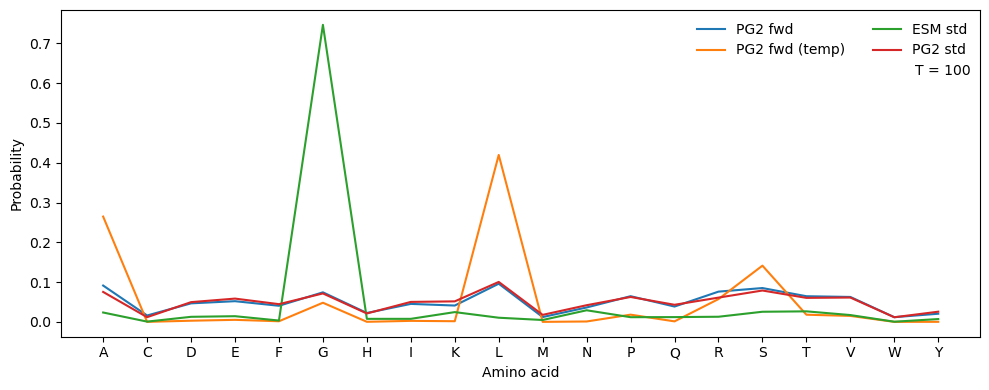

In [66]:
x = np.arange(20)

x = np.arange(len(amino_acids))

plt.figure(figsize=(10, 4))

plt.plot(x, eBf[1], label="PG2 fwd")
plt.plot(x, sfeBf[1], label="PG2 fwd (temp)")
plt.plot(x, eA1[1], label="ESM std")
plt.plot(x, eA2[1], label="PG2 std")

ax = plt.gca()
ax.text(0.99, 0.8, f"T = {T}", transform=ax.transAxes,
        ha="right")

plt.xticks(x, amino_acids)
plt.xlabel("Amino acid")
plt.ylabel("Probability")

plt.legend(frameon=False, ncol=2)
plt.tight_layout()

plt.show()

IndexError: list index out of range

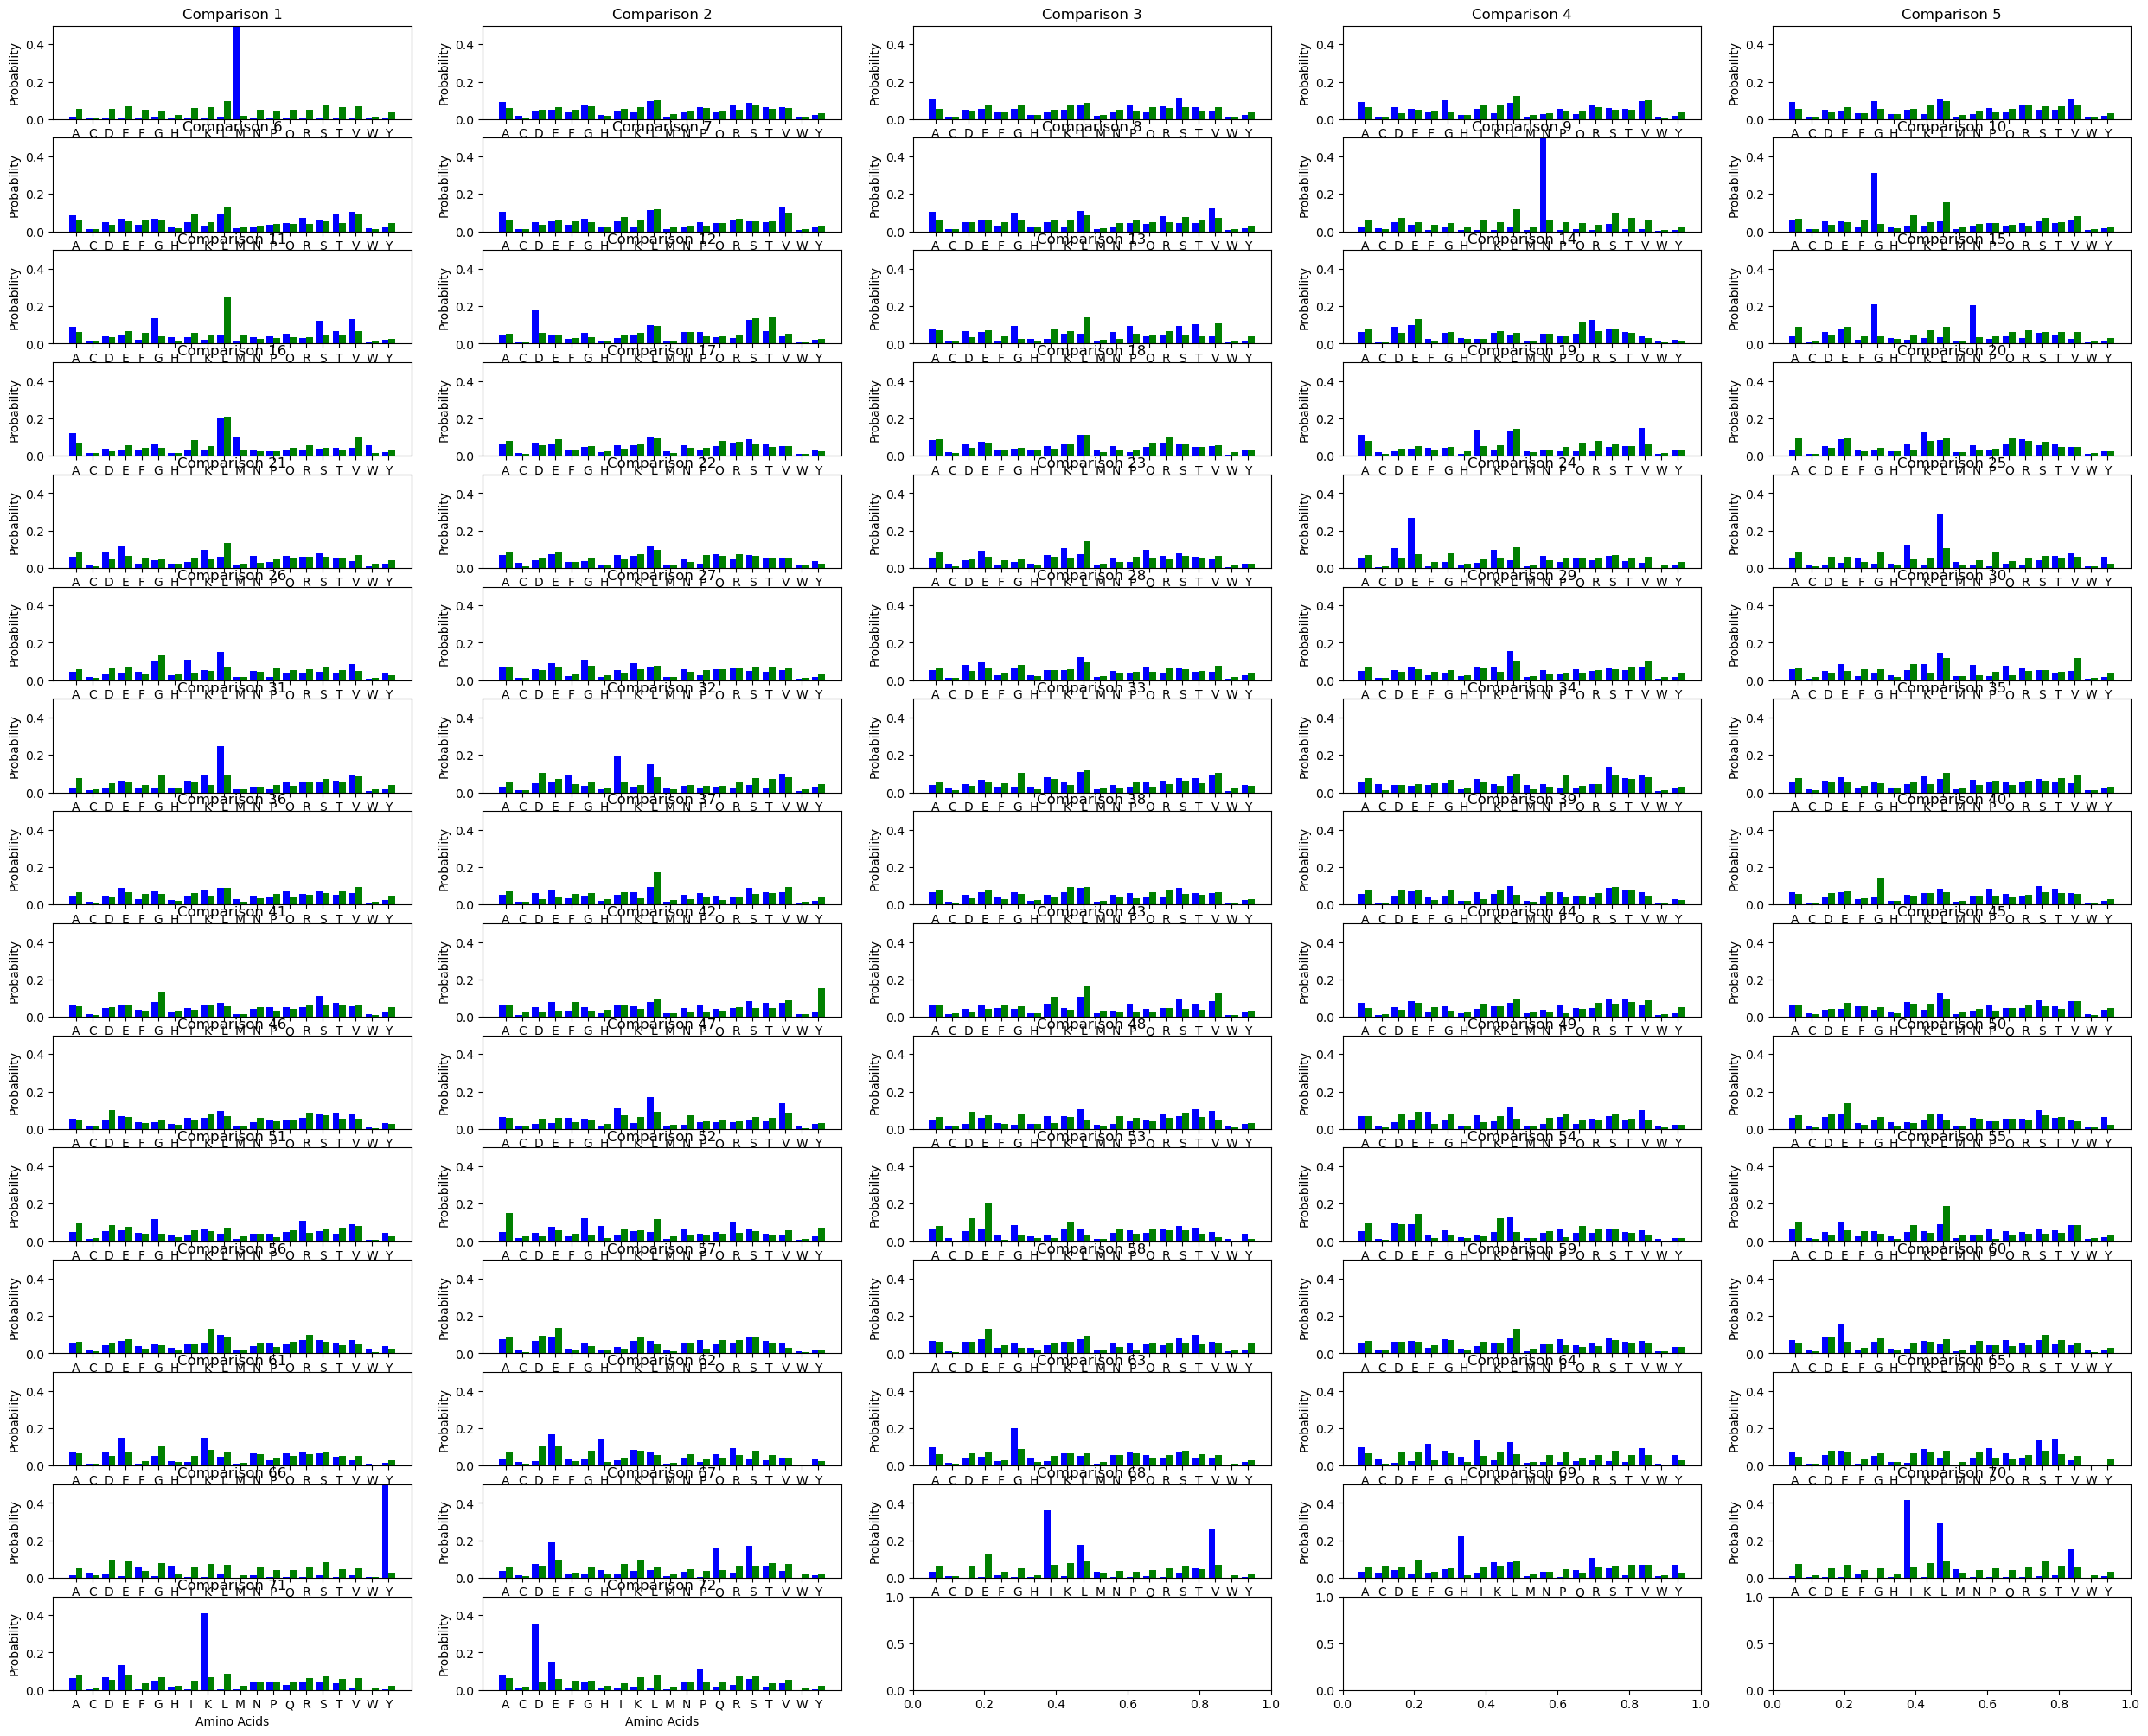

In [45]:
name = 'CBPA2_HUMAN'

A = esm_dict[name]['log_probs']
B = pg_dict[name]['log_probs']
Bf = lp_forward
Bb = lp_backward

eA = np.exp(A)
eB = np.exp(B)
eBf = np.exp(Bf)
eBb = np.exp(Bb)

bound = len(B)

pairs_pgf = [np.array(eBf)[i] for i in range(bound)]
pairs_pgb = [np.array(eBb)[i] for i in range(bound)]

# Plot settings
fig, axes = plt.subplots(15, 5, figsize=(31, 25))
axes = axes.flatten()
bar_width = 0.4
x = torch.arange(1, 21)

for i, ax in enumerate(axes):
    dist1 = pairs_pgf[i]
    dist2 = pairs_pgb[i]
    ax.bar(x - bar_width/2, dist1, width=bar_width, label="Forward", color="blue")
    ax.bar(x + bar_width/2, dist2, width=bar_width, label="Backward", color="green")
    ax.set_title(f"Comparison {i+1}")
    ax.set_xlabel("Amino Acids")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(aa_list)  
    ax.tick_params(axis='x', rotation=0)

# Add a single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

IndexError: list index out of range

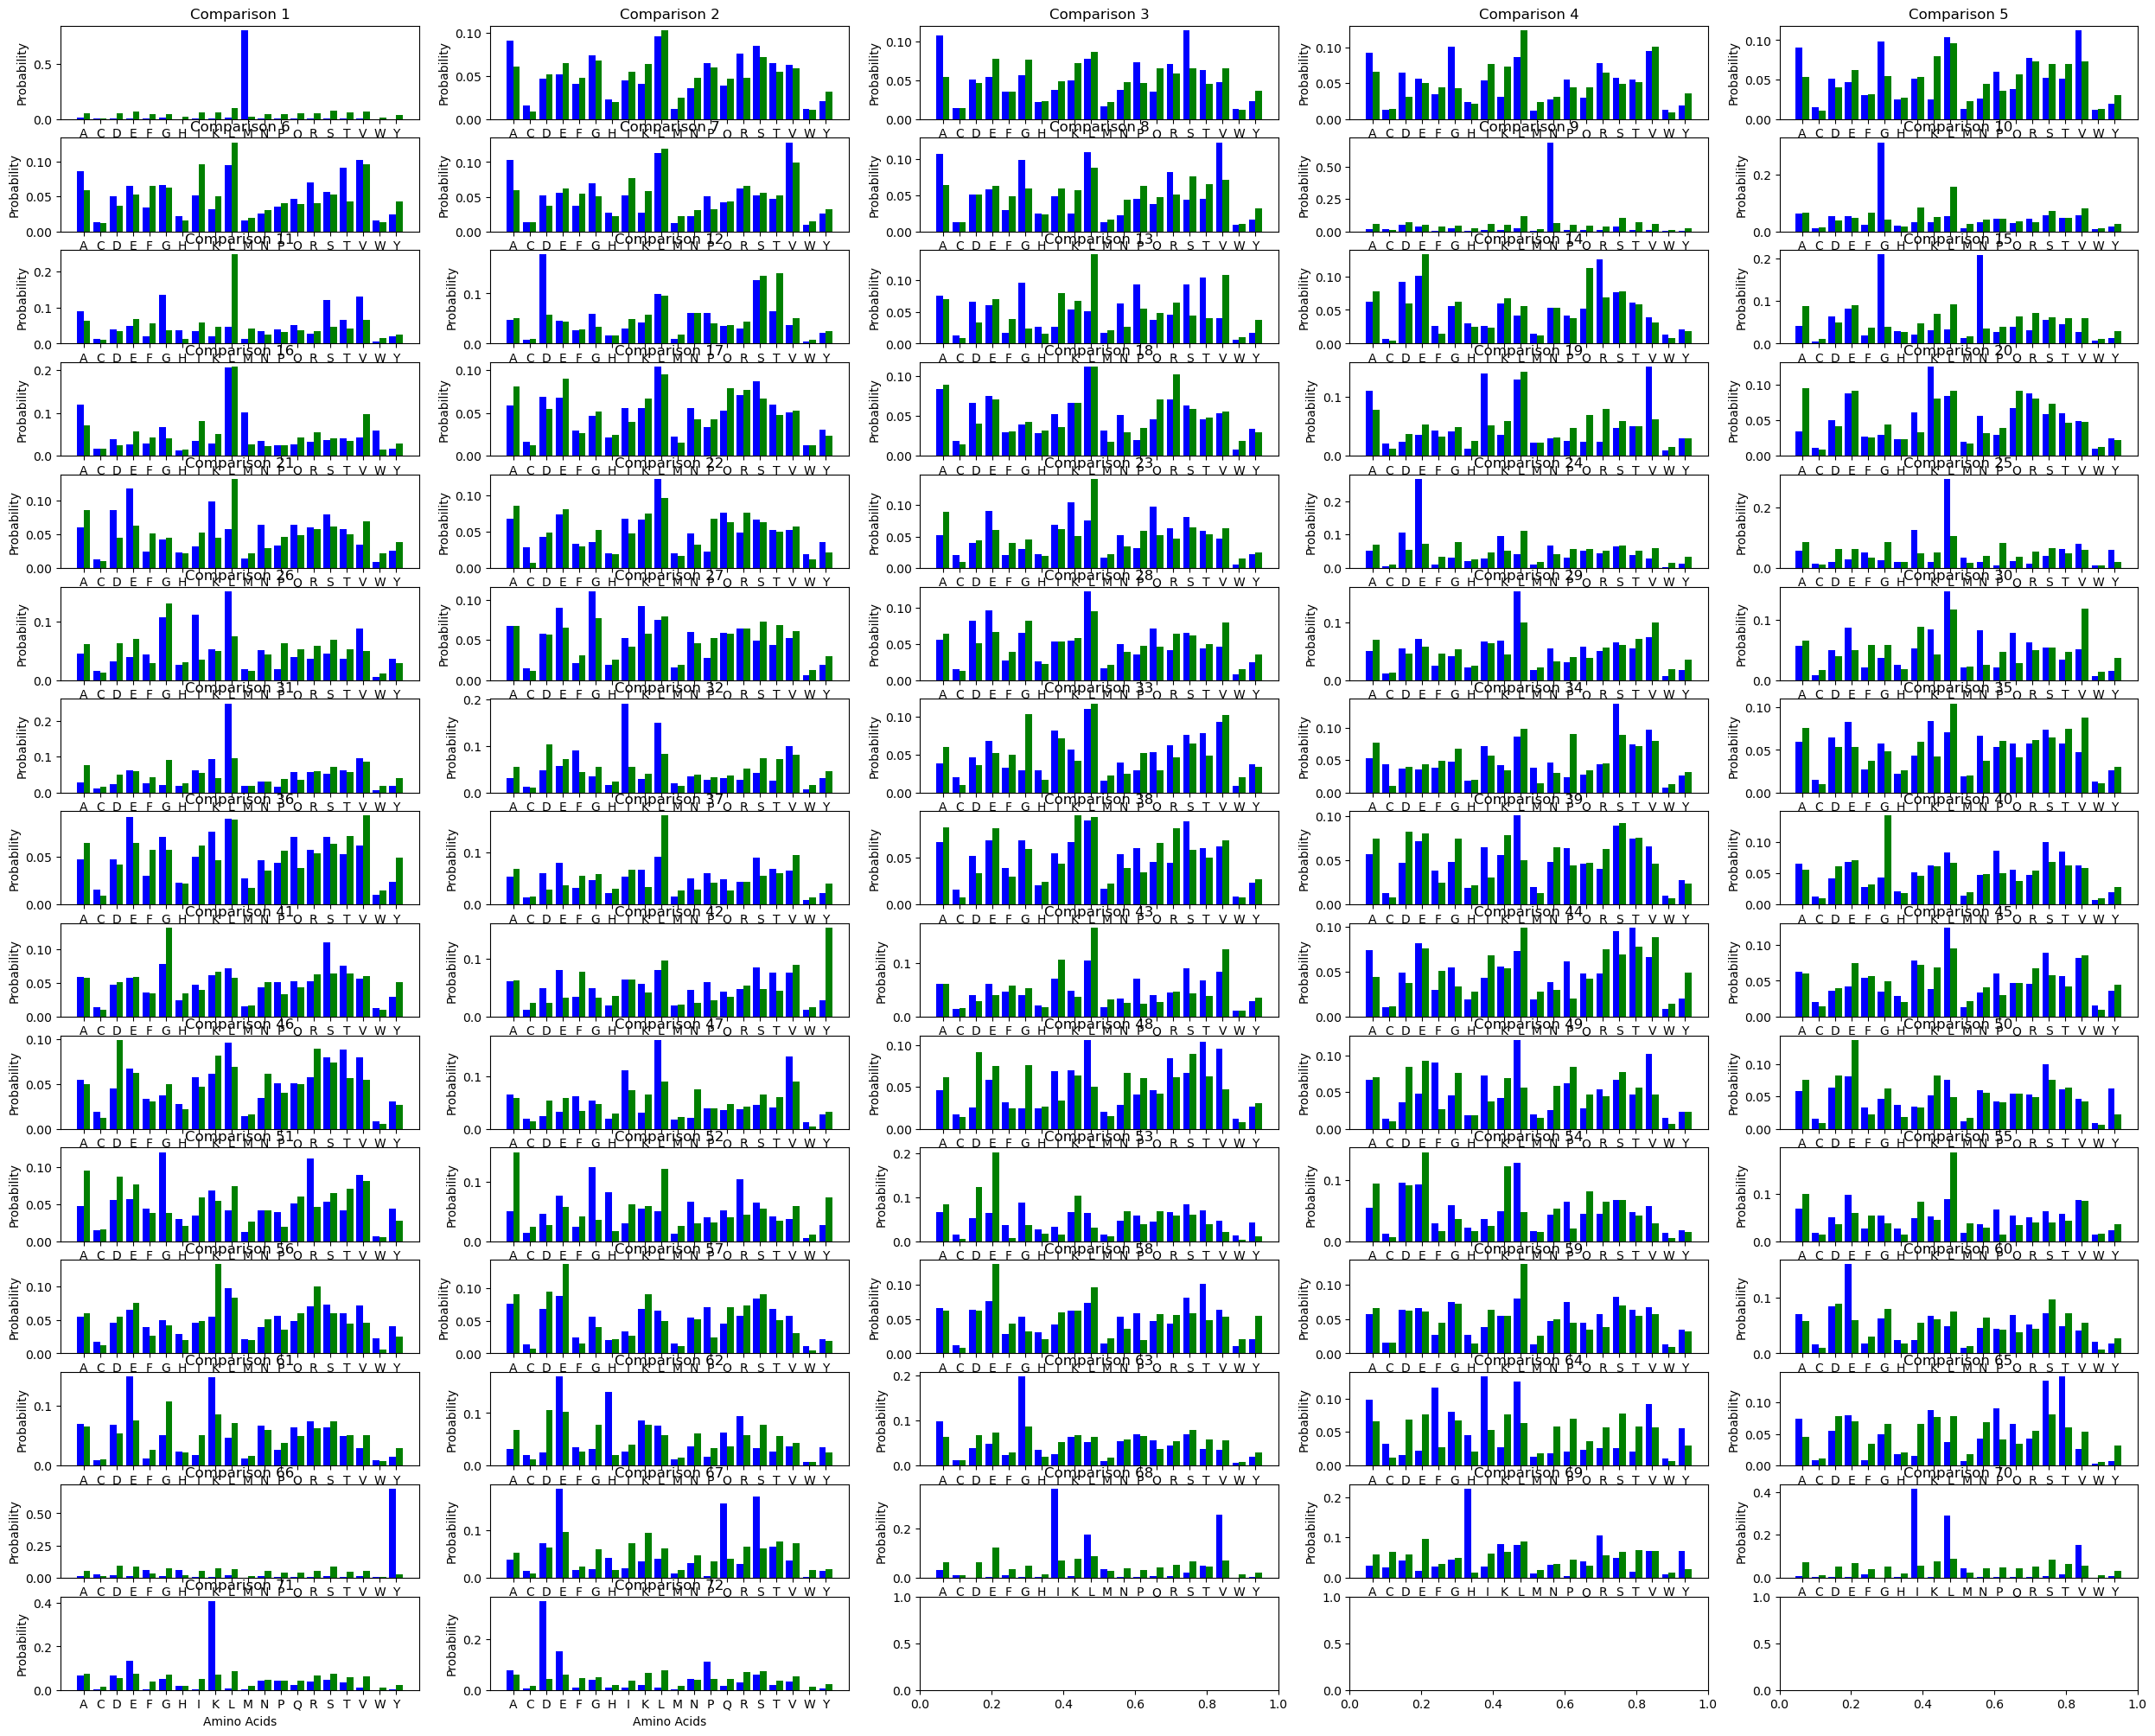

In [67]:
name = 'CBPA2_HUMAN'

A = esm_dict[name]['log_probs']
B = pg_dict[name]['log_probs']
Bf = lp_forward
Bb = lp_backward

eA = np.exp(A)
eB = np.exp(B)
eBf = np.exp(Bf)
eBb = np.exp(Bb)

bound = len(B)

pairs_pgf = [np.array(eBf)[i] for i in range(bound)]
pairs_pgb = [np.array(eBb)[i] for i in range(bound)]

# Plot settings
fig, axes = plt.subplots(15, 5, figsize=(31, 25))
axes = axes.flatten()
bar_width = 0.4
x = torch.arange(1, 21)

for i, ax in enumerate(axes):
    dist1 = pairs_pgf[i]
    dist2 = pairs_pgb[i]
    ax.bar(x - bar_width/2, dist1, width=bar_width, label="Forward", color="blue")
    ax.bar(x + bar_width/2, dist2, width=bar_width, label="Backward", color="green")
    ax.set_title(f"Comparison {i+1}")
    ax.set_xlabel("Amino Acids")
    ax.set_ylabel("Probability")
    #ax.set_ylim(0, 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(aa_list)  
    ax.tick_params(axis='x', rotation=0)

# Add a single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()